In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10 

In [11]:
# Datasets & DataLoaders
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# image => scale (0,1) & normalize => (-1,1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=transform)

In [12]:
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader = DataLoader(testset, batch_size=128)

## Build the CNN

In [13]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernel_size = 2, stride =2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) #flatenning
        x = self.fc_layers(x)

        return x

In [14]:
model = CNN()

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Training the CNN

In [16]:
train_losses = []
val_losses = []

epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output = model(images) #FP
        loss = criterion(output, labels) #loss fnx
        loss.backward() #BP
        optimizer.step() #update params

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(trainloader)
    train_losses.append(epoch_train_loss)
        

    #print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")

    #validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in testloader:
            output = model(images) 
            loss = criterion(output, labels)
            running_val_loss += loss.item()

        epoch_val_loss = running_val_loss / len(testloader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")
        

epoch 1/3 ==> train loss = 1.458533432630017 & val loss = 1.2113859230958963
epoch 2/3 ==> train loss = 1.0485645407605964 & val loss = 0.9836219586903536
epoch 3/3 ==> train loss = 0.8402534119613335 & val loss = 0.8425598310518868


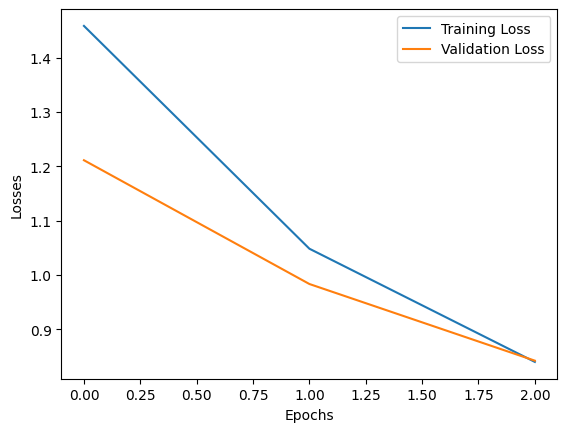

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss" : val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.show()

In [18]:
# Evaluate our CNN

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy={correct_labels / total_labels * 100} ")
    

accuracy=70.19 


In [19]:
import sys
print(sys.executable)

/Users/princesingh/Documents/DS_Projects/CNN project3/venv/bin/python


In [20]:
torch.save(model.state_dict(), "cnn_cifar10.pth")

In [21]:
torch.save(model, "cnn_full_model.pth")